# Day 13 – Feature Engineering + Feature Selection
### 20-Day ML Revision Planner | Phase: Advanced ML

**Topics covered:**
1. Feature Engineering: Numerical Transformations, Log Transformation
2. Polynomial Features, Binning, Interaction Features
3. Date/Time Features, Text Features
4. Feature Selection: Correlation, Variance Threshold
5. Mutual Information, Chi-Square
6. Recursive Feature Elimination (RFE), L1 Regularization
7. Advanced Concept: The Curse of Dimensionality
8. Coding: Improve a Dataset via Feature Engineering + Selection
9. Before/After Model Comparison (Daily Output)
10. Interview Questions
11. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, KBinsDiscretizer
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, mutual_info_regression,
                                         mutual_info_classif, chi2, RFE)
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.datasets import load_breast_cancer

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Numerical Transformations & Log Transformation

### What?
**Feature engineering** is the process of creating new, more informative features from raw data — often mattering more for model performance than the choice of algorithm itself.

**Log transformation**: replacing a skewed feature $x$ with $\log(x)$ (or $\log(1+x)$ to safely handle zeros).

### Why?
- Many real-world variables (income, population, prices) are **right-skewed** — a log transform compresses large values and spreads out small ones, making the distribution more symmetric/Gaussian-like.
- Linear models (Day 5) assume roughly linear relationships and benefit from residuals that are more homoscedastic (Day 5's regression assumptions) — log-transforming a skewed feature or target often improves both.
- Reduces the influence of extreme outliers without discarding them entirely.

### How?
Use `np.log1p(x)` ($=\log(1+x)$) rather than `np.log(x)` when the feature can be zero, to avoid $\log(0) = -\infty$.


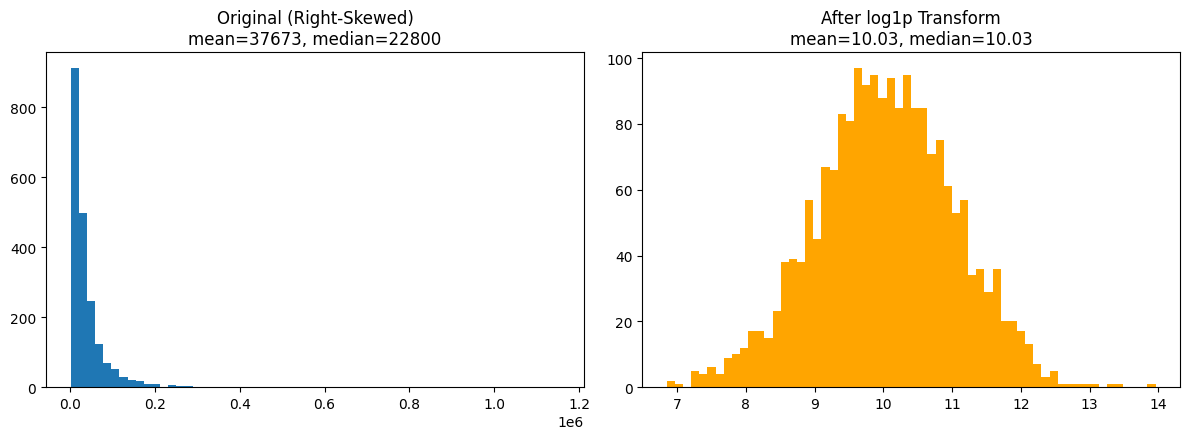

--> The log-transformed feature is far more symmetric, closer to Gaussian --
    exactly what linear models' assumptions (Day 5) prefer.


In [2]:
# Demonstrate log transformation on a right-skewed feature (recall Day 3's skew discussion)
np.random.seed(1)
skewed_income = np.random.lognormal(mean=10, sigma=1, size=2000)

log_income = np.log1p(skewed_income)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(skewed_income, bins=60)
axes[0].set_title(f"Original (Right-Skewed)\nmean={skewed_income.mean():.0f}, median={np.median(skewed_income):.0f}")
axes[1].hist(log_income, bins=60, color='orange')
axes[1].set_title(f"After log1p Transform\nmean={log_income.mean():.2f}, median={np.median(log_income):.2f}")
plt.tight_layout()
plt.show()
print("--> The log-transformed feature is far more symmetric, closer to Gaussian --")
print("    exactly what linear models' assumptions (Day 5) prefer.")


## 2. Polynomial Features, Binning, and Interaction Features

### What?
- **Polynomial features** (recap from Day 5): add $x^2, x^3, \dots$ to let linear models capture curvature.
- **Binning (discretization)**: convert a continuous variable into discrete categories/buckets (e.g., age → "18-25", "26-40", "41-60", "60+").
- **Interaction features**: create new features by combining two (or more) existing ones, e.g., $x_1 \times x_2$, capturing effects that depend on the **combination** of variables, not each independently.

### Why?
- **Binning** can capture **non-linear, non-monotonic** effects a linear model would otherwise miss (e.g., risk might be highest for both very young and very old customers — not a straight line).
- **Interaction features** matter when the effect of one variable **depends on the level of another** (e.g., "rooms per household" is more informative than "rooms" and "household size" separately).

### How?
`PolynomialFeatures(degree=2, interaction_only=True)` in sklearn generates only the interaction terms (excluding pure powers like $x^2$) if you want interactions without polynomial blow-up.


In [3]:
# Binning example: convert a continuous 'age' feature into meaningful buckets
np.random.seed(2)
ages = np.random.randint(18, 80, 500)
age_df = pd.DataFrame({'age': ages})

# Using pandas cut for interpretable custom bins
age_df['age_group'] = pd.cut(age_df['age'], bins=[17, 25, 40, 60, 80],
                               labels=['18-25', '26-40', '41-60', '61-80'])
print(age_df.head(10))
print("\nAge group counts:\n", age_df['age_group'].value_counts().sort_index())

# Using sklearn's KBinsDiscretizer for equal-frequency (quantile) binning
kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
age_df['age_bin_quantile'] = kbins.fit_transform(age_df[['age']]).astype(int)
print("\nQuantile-based bins (equal-frequency, sklearn):")
print(age_df.groupby('age_bin_quantile')['age'].agg(['min', 'max', 'count']))


   age age_group
0   58     41-60
1   33     26-40
2   63     61-80
3   26     26-40
4   40     26-40
5   61     61-80
6   36     26-40
7   29     26-40
8   58     41-60
9   25     18-25

Age group counts:
 age_group
18-25     51
26-40    135
41-60    161
61-80    153
Name: count, dtype: int64

Quantile-based bins (equal-frequency, sklearn):
                  min  max  count
age_bin_quantile                 
0                  18   34    121
1                  35   49    128
2                  50   63    125
3                  64   79    126


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [4]:
# Interaction feature example: does combining features reveal more signal than either alone?
np.random.seed(3)
rooms = np.random.randint(1, 8, 500)
household_size = np.random.randint(1, 6, 500)

# Suppose the TRUE relationship depends on the ratio (an interaction-style feature), not raw values
target = 50 - 8 * (rooms / household_size) + np.random.normal(0, 3, 500)

df_interact = pd.DataFrame({'rooms': rooms, 'household_size': household_size, 'target': target})
df_interact['rooms_per_person'] = df_interact['rooms'] / df_interact['household_size']

corr_rooms = df_interact['rooms'].corr(df_interact['target'])
corr_household = df_interact['household_size'].corr(df_interact['target'])
corr_interaction = df_interact['rooms_per_person'].corr(df_interact['target'])

print(f"Correlation of 'rooms' alone with target:            {corr_rooms:.4f}")
print(f"Correlation of 'household_size' alone with target:    {corr_household:.4f}")
print(f"Correlation of 'rooms_per_person' (interaction) with target: {corr_interaction:.4f}")
print("\n--> The engineered interaction feature captures FAR more signal than either raw feature alone --")
print("    exactly the kind of insight domain knowledge + feature engineering can unlock.")


Correlation of 'rooms' alone with target:            -0.5361
Correlation of 'household_size' alone with target:    0.6126
Correlation of 'rooms_per_person' (interaction) with target: -0.9701

--> The engineered interaction feature captures FAR more signal than either raw feature alone --
    exactly the kind of insight domain knowledge + feature engineering can unlock.


In [5]:
# PolynomialFeatures with interaction_only=True -- generate interaction terms automatically
X_demo_interact = df_interact[['rooms', 'household_size']].values
poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly_interact = poly_interact.fit_transform(X_demo_interact)

print("Generated feature names:", poly_interact.get_feature_names_out(['rooms', 'household_size']))
print("First 5 rows of transformed features:\n", X_poly_interact[:5])


Generated feature names: ['rooms' 'household_size' 'rooms household_size']
First 5 rows of transformed features:
 [[ 3.  2.  6.]
 [ 1.  4.  4.]
 [ 2.  1.  2.]
 [ 4.  5. 20.]
 [ 1.  2.  2.]]


## 3. Date/Time Features & Text Features

### What?
- **Date/time features**: raw timestamps are rarely useful directly — extract meaningful components: day of week, month, hour, is_weekend, days_since_event, cyclical encodings (e.g., sine/cosine of hour-of-day to capture "23:00 and 00:00 are close").
- **Text features**: convert raw text into numeric representations — simplest approaches include text length, word count, and (previewing Day 18) Bag-of-Words / TF-IDF representations.

### Why?
- A raw Unix timestamp or datetime object has **no direct linear relationship** with most targets — a purchase likelihood might spike on weekends and evenings, a pattern only visible once decomposed.
- **Cyclical encoding** matters because naively treating "hour" as a plain integer implies hour 23 and hour 0 are far apart, when they're actually adjacent.

### How?
`pd.to_datetime()` + `.dt` accessor extracts most date components easily; cyclical features use $\sin\left(\frac{2\pi \cdot \text{hour}}{24}\right)$ and $\cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$ pairs.


In [6]:
# Date/time feature engineering demo
np.random.seed(4)
dates = pd.date_range('2024-01-01', periods=500, freq='h')
sample_dates = pd.Series(np.random.choice(dates, 500))

date_features = pd.DataFrame({'timestamp': sample_dates})
date_features['hour'] = date_features['timestamp'].dt.hour
date_features['day_of_week'] = date_features['timestamp'].dt.dayofweek
date_features['month'] = date_features['timestamp'].dt.month
date_features['is_weekend'] = (date_features['day_of_week'] >= 5).astype(int)

# Cyclical encoding for hour (so 23:00 and 00:00 are recognized as close)
date_features['hour_sin'] = np.sin(2 * np.pi * date_features['hour'] / 24)
date_features['hour_cos'] = np.cos(2 * np.pi * date_features['hour'] / 24)

print(date_features.head(8))


            timestamp  hour  day_of_week  month  is_weekend  hour_sin  \
0 2024-01-06 02:00:00     2            5      1           1    0.5000   
1 2024-01-08 06:00:00     6            0      1           0    1.0000   
2 2024-01-19 07:00:00     7            4      1           0    0.9659   
3 2024-01-09 05:00:00     5            1      1           0    0.9659   
4 2024-01-17 01:00:00     1            2      1           0    0.2588   
5 2024-01-16 00:00:00     0            1      1           0    0.0000   
6 2024-01-04 15:00:00    15            3      1           0   -0.7071   
7 2024-01-20 00:00:00     0            5      1           1    0.0000   

     hour_cos  
0  8.6603e-01  
1  6.1232e-17  
2 -2.5882e-01  
3  2.5882e-01  
4  9.6593e-01  
5  1.0000e+00  
6 -7.0711e-01  
7  1.0000e+00  


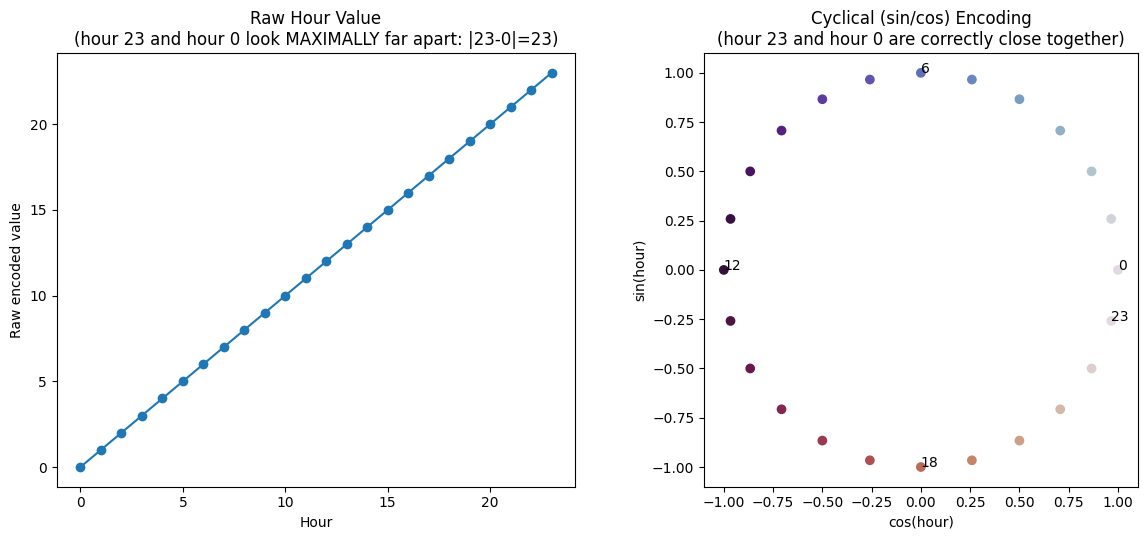

In [7]:
# Visualize WHY cyclical encoding matters: raw hour vs sin/cos representation
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

hours = np.arange(24)
axes[0].plot(hours, hours, marker='o')
axes[0].set_title("Raw Hour Value\n(hour 23 and hour 0 look MAXIMALLY far apart: |23-0|=23)")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Raw encoded value")

hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)
axes[1].scatter(hour_cos, hour_sin, c=hours, cmap='twilight')
for h in [0, 6, 12, 18, 23]:
    axes[1].annotate(str(h), (hour_cos[h], hour_sin[h]))
axes[1].set_title("Cyclical (sin/cos) Encoding\n(hour 23 and hour 0 are correctly close together)")
axes[1].set_xlabel("cos(hour)"); axes[1].set_ylabel("sin(hour)")
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


In [8]:
# Simple text feature engineering demo
sample_texts = pd.Series([
    "Great product, highly recommend!",
    "Terrible experience, would not buy again.",
    "It's okay, does the job.",
    "Absolutely amazing! Best purchase ever!!!",
    "Not worth the price."
])

text_features = pd.DataFrame({'text': sample_texts})
text_features['char_length'] = text_features['text'].str.len()
text_features['word_count'] = text_features['text'].str.split().str.len()
text_features['exclamation_count'] = text_features['text'].str.count('!')
text_features['has_negative_word'] = text_features['text'].str.lower().str.contains('not|terrible|worst').astype(int)

print(text_features)
print("\n--> These simple hand-crafted features already hint at sentiment; Day 18 covers")
print("    proper text vectorization (Bag-of-Words, TF-IDF) for full NLP feature extraction.")


                                        text  char_length  word_count  \
0           Great product, highly recommend!           32           4   
1  Terrible experience, would not buy again.           41           6   
2                   It's okay, does the job.           24           5   
3  Absolutely amazing! Best purchase ever!!!           41           5   
4                       Not worth the price.           20           4   

   exclamation_count  has_negative_word  
0                  1                  0  
1                  0                  1  
2                  0                  0  
3                  4                  0  
4                  0                  1  

--> These simple hand-crafted features already hint at sentiment; Day 18 covers
    proper text vectorization (Bag-of-Words, TF-IDF) for full NLP feature extraction.


## 4. Feature Selection: Correlation & Variance Threshold

### What?
- **Correlation-based selection** (recap Day 3): drop features that are **highly correlated with each other** (redundant, causing multicollinearity — recall Day 1's rank discussion) or **weakly correlated with the target** (uninformative).
- **Variance Threshold**: drop features with **very low variance** — if a feature is (nearly) constant across all samples, it carries little to no discriminative information.

### Why?
Fewer, more relevant features can **reduce overfitting**, **speed up training**, and **improve interpretability** — especially important as feature counts grow (leading into the curse of dimensionality below).

### How?
`VarianceThreshold(threshold=X)` removes features whose variance falls below `X`. For correlation, compute the correlation matrix and drop one feature from each highly-correlated pair (e.g., $|r| > 0.9$).


In [9]:
# Load Breast Cancer dataset for feature selection practice (30 features, several highly correlated)
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y_full = pd.Series(data.target, name='target')

# Variance Threshold demo (scale-sensitive, so we standardize first for a fair illustration on RAW scale here we skip scaling to show raw variances)
variances = X_full.var().sort_values()
print("5 lowest-variance features (raw scale):")
print(variances.head())

selector = VarianceThreshold(threshold=0.01)
# Note: on raw (unscaled) data, variance threshold is scale-dependent; typically applied on standardized
# or naturally-scaled binary/count features. We illustrate the mechanism here:
X_var_filtered = selector.fit_transform(X_full)
print(f"\nFeatures before Variance Threshold: {X_full.shape[1]}")
print(f"Features after Variance Threshold (threshold=0.01): {X_var_filtered.shape[1]}")


5 lowest-variance features (raw scale):
fractal dimension error    7.0017e-06
smoothness error           9.0151e-06
concave points error       3.8072e-05
mean fractal dimension     4.9849e-05
symmetry error             6.8333e-05
dtype: float64

Features before Variance Threshold: 30
Features after Variance Threshold (threshold=0.01): 14


Found 15 feature pairs with correlation > 0.95:
  mean perimeter  <-->  mean radius:  r = 0.998
  mean area  <-->  mean radius:  r = 0.987
  mean area  <-->  mean perimeter:  r = 0.987
  perimeter error  <-->  radius error:  r = 0.973
  area error  <-->  radius error:  r = 0.952
  worst radius  <-->  mean radius:  r = 0.970
  worst radius  <-->  mean perimeter:  r = 0.969
  worst radius  <-->  mean area:  r = 0.963

Features to drop (keeping one from each highly-correlated pair): 7
Remaining features after correlation filtering: 23


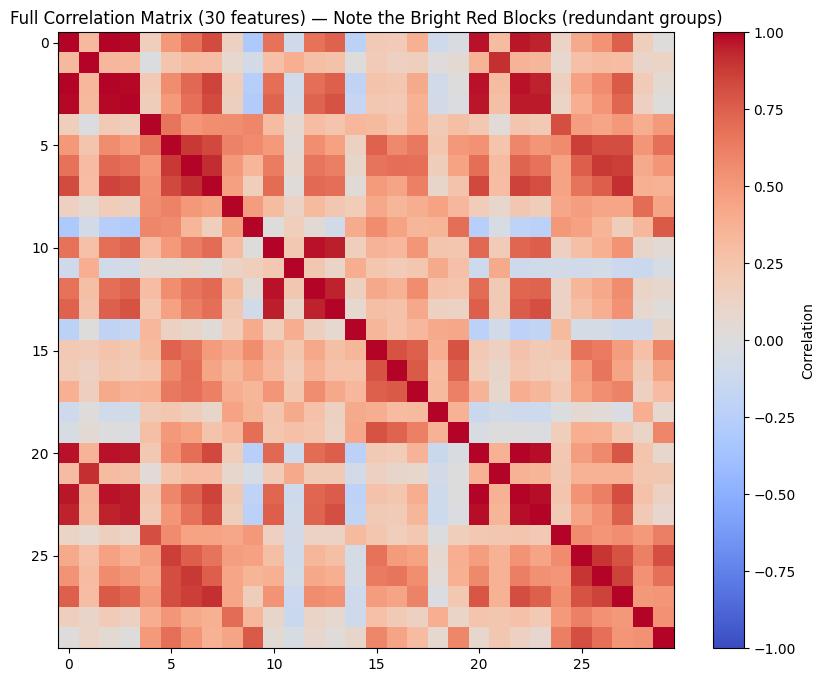

In [10]:
# Correlation-based feature selection: find and remove highly correlated feature pairs
corr_matrix = X_full.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.95 to some other feature
high_corr_pairs = [(col, row, upper_triangle.loc[row, col])
                    for col in upper_triangle.columns
                    for row in upper_triangle.index
                    if pd.notna(upper_triangle.loc[row, col]) and upper_triangle.loc[row, col] > 0.95]

print(f"Found {len(high_corr_pairs)} feature pairs with correlation > 0.95:")
for f1, f2, corr_val in high_corr_pairs[:8]:
    print(f"  {f1}  <-->  {f2}:  r = {corr_val:.3f}")

to_drop = set(pair[0] for pair in high_corr_pairs)
print(f"\nFeatures to drop (keeping one from each highly-correlated pair): {len(to_drop)}")
print(f"Remaining features after correlation filtering: {X_full.shape[1] - len(to_drop)}")

plt.figure(figsize=(10, 8))
plt.imshow(X_full.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Full Correlation Matrix (30 features) — Note the Bright Red Blocks (redundant groups)")
plt.show()


## 5. Mutual Information & Chi-Square

### What?
- **Mutual Information (MI)**: measures how much knowing one variable **reduces uncertainty** about another — captures **both linear AND non-linear** relationships (unlike Pearson correlation, recall Day 3's non-linear correlation example). MI = 0 means the variables are truly independent.
- **Chi-Square Test**: a statistical test measuring whether two **categorical** variables are independent — commonly used to test whether a categorical feature is associated with a categorical target.

### Why?
- Pearson correlation (Day 3) only captures **linear** relationships — MI catches relationships correlation would completely miss (recall Day 3's $y=x^2$ example, where correlation ≈ 0 despite a perfect relationship).
- Chi-Square is the natural choice for **categorical feature vs. categorical target** relationships, where correlation/MI-for-continuous-data don't directly apply.

### How?
`mutual_info_classif`/`mutual_info_regression` in sklearn estimate MI between each feature and the target; `chi2` requires **non-negative** features (often counts or one-hot encoded categories).


Top 10 features by Mutual Information vs their Pearson correlation:
                      Mutual Information  Abs Pearson Correlation
worst perimeter                   0.4718                   0.7829
worst area                        0.4643                   0.7338
worst radius                      0.4512                   0.7765
mean concave points               0.4388                   0.7766
worst concave points              0.4363                   0.7936
mean perimeter                    0.4024                   0.7426
mean concavity                    0.3754                   0.6964
mean radius                       0.3623                   0.7300
mean area                         0.3600                   0.7090
area error                        0.3408                   0.5482


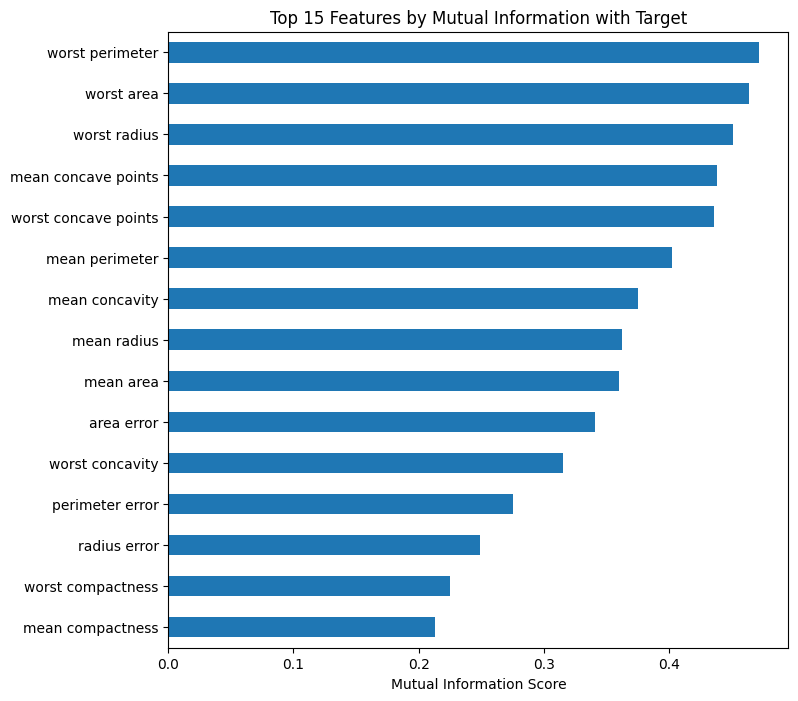

In [11]:
# Mutual Information: rank features by MI with the target, compare to Pearson correlation ranking
mi_scores = mutual_info_classif(X_full, y_full, random_state=42)
mi_series = pd.Series(mi_scores, index=X_full.columns).sort_values(ascending=False)

corr_with_target = X_full.corrwith(y_full).abs().sort_values(ascending=False)

comparison_ranking = pd.DataFrame({
    'Mutual Information': mi_series,
    'Abs Pearson Correlation': corr_with_target
}).sort_values('Mutual Information', ascending=False)

print("Top 10 features by Mutual Information vs their Pearson correlation:")
print(comparison_ranking.head(10))

plt.figure(figsize=(8, 8))
comparison_ranking.head(15)['Mutual Information'].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Mutual Information with Target")
plt.xlabel("Mutual Information Score")
plt.show()


In [12]:
# Chi-Square test demo on a categorical dataset (needs non-negative features -- use binned/count data)
np.random.seed(5)
n = 500
categorical_df = pd.DataFrame({
    'city_code': np.random.randint(0, 4, n),          # 4 categories, encoded as non-negative integers
    'plan_type_code': np.random.randint(0, 3, n),      # 3 categories
    'random_noise_code': np.random.randint(0, 5, n),   # irrelevant categorical noise
})
# Target depends on city_code and plan_type_code, NOT on random_noise_code
categorical_target = ((categorical_df['city_code'] >= 2) & (categorical_df['plan_type_code'] >= 1)).astype(int)

chi2_scores, p_values = chi2(categorical_df, categorical_target)
chi2_results = pd.DataFrame({'Feature': categorical_df.columns, 'Chi2 Score': chi2_scores, 'p-value': p_values})
chi2_results = chi2_results.sort_values('Chi2 Score', ascending=False)
print(chi2_results)
print("\n--> Low p-values (<0.05) for city_code/plan_type_code indicate a statistically significant")
print("    association with the target; random_noise_code correctly shows a high p-value (not significant).")


             Feature  Chi2 Score     p-value
0          city_code    186.1588  2.1920e-42
1     plan_type_code     52.5898  4.1102e-13
2  random_noise_code      0.3207  5.7118e-01

--> Low p-values (<0.05) for city_code/plan_type_code indicate a statistically significant
    association with the target; random_noise_code correctly shows a high p-value (not significant).


## 6. Recursive Feature Elimination (RFE) & L1 Regularization

### What?
- **RFE (Recursive Feature Elimination)**: iteratively **trains a model**, ranks features by importance/coefficient magnitude, **removes the weakest** feature(s), and repeats until the desired number of features remains.
- **L1 Regularization (Lasso, recap from Day 5)**: automatically drives **uninformative feature coefficients to exactly zero** during training — a built-in, "free" feature selection mechanism.

### Why?
- RFE directly optimizes for **model-specific** feature importance rather than a generic statistical criterion (correlation/MI) — it accounts for feature interactions the model itself learns.
- L1 regularization gives feature selection "for free" as a side effect of regularized training (recall Day 5's coefficient-shrinkage-to-zero visualization) — no separate selection step required.

### How?
`RFE(estimator, n_features_to_select=k)` wraps any model with a `coef_` or `feature_importances_` attribute; Lasso's zero-coefficient features are simply the ones it selected against.


In [13]:
# RFE demo: recursively eliminate features using Logistic Regression as the base estimator
scaler_rfe = StandardScaler()
X_full_scaled = scaler_rfe.fit_transform(X_full)

rfe_selector = RFE(estimator=LogisticRegression(max_iter=5000), n_features_to_select=10, step=1)
rfe_selector.fit(X_full_scaled, y_full)

selected_features_rfe = X_full.columns[rfe_selector.support_]
print(f"RFE selected {len(selected_features_rfe)} out of {X_full.shape[1]} features:")
print(list(selected_features_rfe))

# Show the elimination ranking for ALL features (1 = selected, higher = eliminated earlier)
ranking_df = pd.Series(rfe_selector.ranking_, index=X_full.columns).sort_values()
print("\nFeature elimination ranking (1 = kept, higher = removed earlier in the process):")
print(ranking_df.head(15))


RFE selected 10 out of 30 features:
['mean concave points', 'radius error', 'area error', 'compactness error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']

Feature elimination ranking (1 = kept, higher = removed earlier in the process):
mean concave points     1
compactness error       1
area error              1
radius error            1
worst radius            1
worst texture           1
worst perimeter         1
worst area              1
worst concave points    1
worst concavity         1
worst smoothness        2
mean area               3
perimeter error         4
mean compactness        5
worst symmetry          6
dtype: int64


In [14]:
# L1 (Lasso) automatic feature selection -- recap and reinforcement from Day 5
lasso_selector = Lasso(alpha=0.05, max_iter=10000)
lasso_selector.fit(X_full_scaled, y_full)

lasso_selected = X_full.columns[np.abs(lasso_selector.coef_) > 1e-4]
lasso_zeroed = X_full.columns[np.abs(lasso_selector.coef_) <= 1e-4]

print(f"Lasso KEPT {len(lasso_selected)} features (non-zero coefficients):")
print(list(lasso_selected))
print(f"\nLasso ZEROED OUT {len(lasso_zeroed)} features:")
print(list(lasso_zeroed))

# Compare RFE's selection vs Lasso's selection -- do they agree?
overlap = set(selected_features_rfe) & set(lasso_selected)
print(f"\nOverlap between RFE's and Lasso's selected features: {len(overlap)} features in common")


Lasso KEPT 6 features (non-zero coefficients):


['mean concave points', 'worst radius', 'worst texture', 'worst smoothness', 'worst concave points', 'worst symmetry']

Lasso ZEROED OUT 24 features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst perimeter', 'worst area', 'worst compactness', 'worst concavity', 'worst fractal dimension']

Overlap between RFE's and Lasso's selected features: 4 features in common


## 7. Advanced Concept: The Curse of Dimensionality

### What?
As the number of features (dimensions) grows, several counter-intuitive problems emerge:
- **Data becomes increasingly sparse**: the volume of space grows exponentially with dimensions, so a fixed number of samples covers a vanishingly small fraction of that space.
- **Distances become less meaningful**: in high dimensions, the ratio between the nearest and farthest neighbor distances tends toward 1 — everything becomes "roughly equidistant," severely hurting distance-based methods (KNN, K-Means — recall Day 6/Day 11).
- **Overfitting risk increases**: more features (relative to sample size) give a model more ways to fit noise (recall Day 4/5's overfitting discussions).

### Why?
This is precisely **why** feature selection, feature engineering, and dimensionality reduction (Day 12's PCA) matter so much — "more features" is not automatically "more signal"; past a point, it actively degrades many algorithms.

### How to mitigate it?
- Feature selection (this day's focus) — keep only informative features.
- Dimensionality reduction (Day 12) — PCA, t-SNE, UMAP.
- Regularization (Day 5) — Ridge/Lasso penalize excessive reliance on many features.
- Collecting more data (samples) to better fill the higher-dimensional space, when feasible.


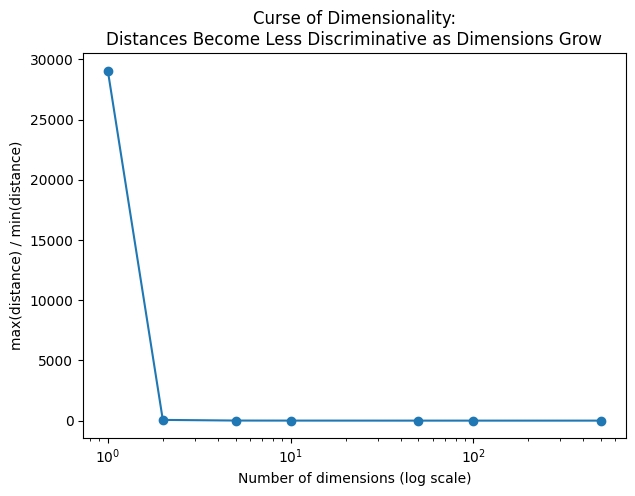

Ratio of farthest to nearest neighbor distance by dimension:
     1 dimensions: ratio = 29066.801
     2 dimensions: ratio = 60.905
     5 dimensions: ratio = 7.237
    10 dimensions: ratio = 3.363
    50 dimensions: ratio = 1.477
   100 dimensions: ratio = 1.305
   500 dimensions: ratio = 1.127

--> As dimensions increase, this ratio approaches 1 -- meaning ALL points become roughly
    equidistant, which is devastating for distance-based algorithms like KNN and K-Means.


In [15]:
# Visualize the curse of dimensionality: distance concentration as dimensions increase
np.random.seed(6)
n_points = 1000
dimensions_to_test = [1, 2, 5, 10, 50, 100, 500]

ratio_results = []
for dim in dimensions_to_test:
    points = np.random.uniform(0, 1, (n_points, dim))
    origin = np.zeros(dim)
    distances = np.linalg.norm(points - origin, axis=1)
    ratio = distances.max() / distances.min()
    ratio_results.append(ratio)

plt.figure(figsize=(7, 5))
plt.plot(dimensions_to_test, ratio_results, marker='o')
plt.xscale('log')
plt.xlabel("Number of dimensions (log scale)")
plt.ylabel("max(distance) / min(distance)")
plt.title("Curse of Dimensionality:\nDistances Become Less Discriminative as Dimensions Grow")
plt.show()

print("Ratio of farthest to nearest neighbor distance by dimension:")
for dim, ratio in zip(dimensions_to_test, ratio_results):
    print(f"  {dim:>4} dimensions: ratio = {ratio:.3f}")
print("\n--> As dimensions increase, this ratio approaches 1 -- meaning ALL points become roughly")
print("    equidistant, which is devastating for distance-based algorithms like KNN and K-Means.")


## 8. Coding Practice — Improve a Dataset via Feature Engineering + Selection

**Goal:** Apply engineered features and selection to the California Housing dataset, then measure whether it actually improves a downstream model — the required "before/after" comparison.


In [16]:
# Load the California Housing dataset (with synthetic fallback if offline)
try:
    housing = fetch_california_housing(as_frame=True)
    house_df = housing.frame
except Exception:
    np.random.seed(40)
    n = 3000
    house_df = pd.DataFrame({
        'MedInc': np.random.gamma(5, 1.5, n),
        'HouseAge': np.random.uniform(1, 52, n),
        'AveRooms': np.random.normal(5.5, 1.2, n),
        'AveBedrms': np.random.normal(1.1, 0.2, n),
        'Population': np.random.exponential(1200, n),
        'AveOccup': np.random.normal(3, 0.8, n),
        'Latitude': np.random.uniform(32, 42, n),
        'Longitude': np.random.uniform(-124, -114, n),
    })
    house_df['MedHouseVal'] = (0.4*house_df['MedInc'] - 0.01*house_df['HouseAge'] +
                                0.05*house_df['AveRooms'] + np.random.normal(0, 0.5, n)).clip(lower=0.3)

print("Original features:", list(house_df.drop(columns=['MedHouseVal']).columns))
house_df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Original features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,5.2101,25.7941,7.5731,0.9082,122.5670,1.9898,36.6516,-119.6831,1.6726
1,6.5992,32.3230,2.3936,0.9274,967.0748,2.8899,32.9641,-123.9202,2.5291
2,2.5630,14.8344,4.6034,0.6650,532.7466,3.1514,40.8022,-117.6810,0.9608
3,5.5932,50.9945,6.3779,1.1737,205.9886,2.6973,41.1723,-114.5665,2.6265
4,9.5630,22.3268,7.7876,1.1247,1128.7924,3.2063,37.7209,-118.3798,4.2049


In [17]:
# BASELINE: train a Linear Regression model on the RAW features only
X_baseline = house_df.drop(columns=['MedHouseVal'])
y_baseline = house_df['MedHouseVal']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, test_size=0.25, random_state=42)

scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

baseline_model = LinearRegression().fit(X_train_base_scaled, y_train_base)
baseline_preds = baseline_model.predict(X_test_base_scaled)

baseline_rmse = np.sqrt(mean_squared_error(y_test_base, baseline_preds))
baseline_r2 = r2_score(y_test_base, baseline_preds)

print(f"BASELINE (raw features) — RMSE: {baseline_rmse:.4f}, R2: {baseline_r2:.4f}")


BASELINE (raw features) — RMSE: 0.5137, R2: 0.8743


In [18]:
# ENGINEERED: create new, more informative features using domain knowledge
house_engineered = house_df.copy()

# Interaction / ratio features (recall Section 2's insight -- ratios often beat raw values)
house_engineered['rooms_per_household'] = house_engineered['AveRooms'] / house_engineered['AveOccup']
house_engineered['bedrooms_per_room'] = house_engineered['AveBedrms'] / house_engineered['AveRooms']
house_engineered['population_per_household'] = house_engineered['Population'] / house_engineered['AveOccup']

# Log transform for right-skewed features (recall Section 1)
house_engineered['log_population'] = np.log1p(house_engineered['Population'])

# Binning house age into life-stage categories (recall Section 2)
house_engineered['age_group'] = pd.cut(house_engineered['HouseAge'], bins=[0, 15, 30, 45, 60],
                                         labels=[0, 1, 2, 3]).astype(float)

print("New engineered features added:")
print(['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'log_population', 'age_group'])
house_engineered.head()


New engineered features added:
['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'log_population', 'age_group']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_household,bedrooms_per_room,population_per_household,log_population,age_group
0,5.2101,25.7941,7.5731,0.9082,122.5670,1.9898,36.6516,-119.6831,1.6726,3.8060,0.1199,61.5988,4.8168,1.0
1,6.5992,32.3230,2.3936,0.9274,967.0748,2.8899,32.9641,-123.9202,2.5291,0.8283,0.3875,334.6402,6.8753,2.0
2,2.5630,14.8344,4.6034,0.6650,532.7466,3.1514,40.8022,-117.6810,0.9608,1.4607,0.1445,169.0516,6.2799,0.0
3,5.5932,50.9945,6.3779,1.1737,205.9886,2.6973,41.1723,-114.5665,2.6265,2.3645,0.1840,76.3682,5.3327,3.0
4,9.5630,22.3268,7.7876,1.1247,1128.7924,3.2063,37.7209,-118.3798,4.2049,2.4289,0.1444,352.0552,7.0298,1.0


In [19]:
# Check correlation of NEW engineered features with the target, vs original features
target_col = 'MedHouseVal'
new_feature_corrs = house_engineered[['rooms_per_household', 'bedrooms_per_room',
                                        'population_per_household', 'log_population', 'age_group',
                                        target_col]].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
original_feature_corrs = house_df.drop(columns=[target_col]).corrwith(house_df[target_col]).abs().sort_values(ascending=False)

print("Correlation of NEW engineered features with target:")
print(new_feature_corrs)
print("\nCorrelation of ORIGINAL features with target (for comparison):")
print(original_feature_corrs)


Correlation of NEW engineered features with target:
age_group                   0.1169
bedrooms_per_room           0.0330
log_population              0.0282
population_per_household    0.0165
rooms_per_household         0.0074
Name: MedHouseVal, dtype: float64

Correlation of ORIGINAL features with target (for comparison):
MedInc        0.9306
HouseAge      0.1231
AveRooms      0.0436
AveOccup      0.0430
Latitude      0.0257
Population    0.0142
AveBedrms     0.0105
Longitude     0.0067
dtype: float64


In [20]:
# Train on ORIGINAL + ENGINEERED features together, then apply feature selection
X_engineered = house_engineered.drop(columns=[target_col])
y_engineered = house_engineered[target_col]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y_engineered, test_size=0.25, random_state=42)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# Model on ALL features (original + engineered), no selection yet
model_all_features = LinearRegression().fit(X_train_eng_scaled, y_train_eng)
preds_all_features = model_all_features.predict(X_test_eng_scaled)
rmse_all = np.sqrt(mean_squared_error(y_test_eng, preds_all_features))
r2_all = r2_score(y_test_eng, preds_all_features)

print(f"ORIGINAL + ENGINEERED (all features, no selection) — RMSE: {rmse_all:.4f}, R2: {r2_all:.4f}")
print(f"Number of features: {X_engineered.shape[1]} (was {X_baseline.shape[1]})")


ORIGINAL + ENGINEERED (all features, no selection) — RMSE: 0.5172, R2: 0.8725
Number of features: 13 (was 8)


In [21]:
# Now apply FEATURE SELECTION (RFE) on top of the engineered feature set
rfe_house = RFE(estimator=LinearRegression(), n_features_to_select=6, step=1)
rfe_house.fit(X_train_eng_scaled, y_train_eng)

selected_cols = X_engineered.columns[rfe_house.support_]
print("RFE-selected features from the engineered set:", list(selected_cols))

X_train_selected = X_train_eng_scaled[:, rfe_house.support_]
X_test_selected = X_test_eng_scaled[:, rfe_house.support_]

model_selected = LinearRegression().fit(X_train_selected, y_train_eng)
preds_selected = model_selected.predict(X_test_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test_eng, preds_selected))
r2_selected = r2_score(y_test_eng, preds_selected)

print(f"\nENGINEERED + SELECTED ({len(selected_cols)} features) — RMSE: {rmse_selected:.4f}, R2: {r2_selected:.4f}")


RFE-selected features from the engineered set: ['MedInc', 'HouseAge', 'AveRooms', 'rooms_per_household', 'log_population', 'age_group']

ENGINEERED + SELECTED (6 features) — RMSE: 0.5162, R2: 0.8731


## 9. Before/After Model Comparison (Daily Output)


                                 Num Features    RMSE      R2
Stage                                                        
Baseline (raw features)                     8  0.5137  0.8743
All features (raw + engineered)            13  0.5172  0.8725
Engineered + Selected (RFE)                 6  0.5162  0.8731


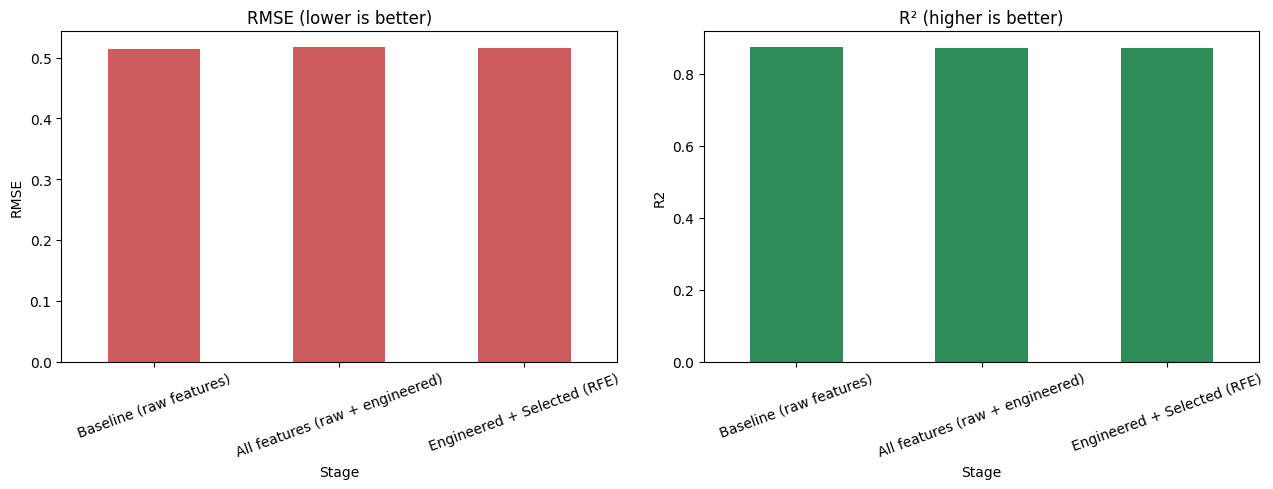


RMSE improved by -0.49% from baseline to engineered+selected,
while using 6 features instead of 8 original ones
(13 were available after engineering, before selection trimmed them down).


In [22]:
# Required daily output: clear before/after comparison table + chart
before_after = pd.DataFrame([
    {'Stage': 'Baseline (raw features)', 'Num Features': X_baseline.shape[1], 'RMSE': baseline_rmse, 'R2': baseline_r2},
    {'Stage': 'All features (raw + engineered)', 'Num Features': X_engineered.shape[1], 'RMSE': rmse_all, 'R2': r2_all},
    {'Stage': 'Engineered + Selected (RFE)', 'Num Features': len(selected_cols), 'RMSE': rmse_selected, 'R2': r2_selected},
]).set_index('Stage')

print(before_after.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
before_after['RMSE'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title("RMSE (lower is better)"); axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=20)

before_after['R2'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("R² (higher is better)"); axes[1].set_ylabel("R2")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

improvement_rmse = (baseline_rmse - rmse_selected) / baseline_rmse
print(f"\nRMSE improved by {improvement_rmse:.2%} from baseline to engineered+selected,")
print(f"while using {len(selected_cols)} features instead of {X_baseline.shape[1]} original ones")
print(f"({X_engineered.shape[1]} were available after engineering, before selection trimmed them down).")


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Log transformation | Day 3's skew discussion, Day 5's regression assumptions |
| Correlation-based selection | Day 3's correlation, Day 1's rank/multicollinearity |
| Mutual Information | Day 3's non-linear correlation limitation (the $y=x^2$ example) |
| RFE | Any model with coefficients/importances (Day 5's linear models, Day 7's trees) |
| L1 (Lasso) selection | Day 5's Ridge/Lasso coefficient shrinkage-to-zero |
| Curse of dimensionality | Day 6/11's distance-based methods (KNN, K-Means), Day 12's PCA as a mitigation |


## 10. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why might you apply a log transformation to a feature or target variable?**
   *Hint: reduces right-skew, makes distributions more symmetric/Gaussian-like, stabilizes variance, reduces outlier influence — helps linear models' assumptions.*

2. **What's the advantage of Mutual Information over Pearson correlation for feature selection?**
   *Hint: MI captures both linear AND non-linear relationships; correlation only captures linear ones (recall Day 3's $y=x^2$ example).*

3. **Explain how Recursive Feature Elimination (RFE) works.**
   *Hint: iteratively train a model, rank features by importance/coefficients, remove the weakest, repeat until the desired count remains.*

4. **How does L1 regularization perform feature selection "for free"?**
   *Hint: the L1 penalty's geometry drives uninformative feature coefficients to exactly zero during normal model training (Day 5).*

5. **What is the curse of dimensionality, and why does it matter for distance-based algorithms?**
   *Hint: as dimensions increase, distances between points become less discriminative (nearest and farthest neighbor distances converge), severely hurting KNN/K-Means.*

6. **Why might binning a continuous variable sometimes help a linear model?**
   *Hint: captures non-monotonic relationships (e.g., U-shaped effects) that a single linear term cannot represent.*

7. **(Bonus) Why is cyclical (sin/cos) encoding preferred over raw integer encoding for a feature like hour-of-day?**
   *Hint: raw integers imply hour 23 and hour 0 are maximally far apart, when they're actually adjacent in time; sin/cos encoding correctly represents this cyclical adjacency.*


## 11. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain log transformation and when it helps.
- [ ] Explain binning and interaction features, and give an example where each adds value beyond raw features.
- [ ] Explain cyclical encoding for date/time features and why it's needed.
- [ ] Compare correlation-based, variance-threshold, mutual-information, and chi-square feature selection methods.
- [ ] Explain RFE and how it differs from a purely statistical (correlation/MI) selection method.
- [ ] Explain how Lasso performs implicit feature selection.
- [ ] Explain the curse of dimensionality and name at least 2 ways to mitigate it.
- [ ] Engineer new features for a dataset and measure their impact on a downstream model.

### 📌 Daily Output (per the planner)
A **before/after model comparison** (Section 9) on the California Housing dataset: baseline (raw features) vs. all features (raw + engineered) vs. engineered + RFE-selected features, compared on RMSE and R², showing the concrete improvement from thoughtful feature engineering and selection.

Close this notebook and re-derive, from memory, why the engineered `rooms_per_household`-style ratio features outperformed their raw component features — that's the real test of Day 13 mastery.
